In [ ]:
import numpy as np
from scipy.optimize import fsolve

# Function to calculate the polynomial (equation 13)
def polynomial_equation(delta, *args):
    M, silhouette_values, delta_values = args
    polynomial = sum([silhouette_values[m] * np.prod([(delta - delta_values[k]) / (delta_values[m] - delta_values[k]) for k in range(M) if k != m]) for m in range(M)])
    return polynomial

def calculate_optimal_threshold(silhouette_values, delta_values):
    M = len(delta_values)
    initial_guess = np.mean(delta_values)
    roots = fsolve(polynomial_equation, initial_guess, args=(M, silhouette_values, delta_values))

    max_silhouette = -np.inf
    optimal_threshold = None

    for root in roots:
        silhouette_at_root = polynomial_equation(root, M, silhouette_values, delta_values)
        if silhouette_at_root > max_silhouette:
            max_silhouette = silhouette_at_root
            optimal_threshold = root

    beta_values = [optimal_threshold / delta_m for delta_m in delta_values]

    return optimal_threshold, beta_values

# Simulating the process for multiple clusters
num_clusters_list = [2, 3]
table_data = []

for num_clusters in num_clusters_list:
    # Simulate data for delta and silhouette values (customize according to your actual values)
    delta_values_clusters = np.random.rand(num_clusters)
    silhouette_values_clusters = np.random.rand(num_clusters)

    # Calculate optimal threshold and beta values
    optimal_threshold_value, beta_values_clusters = calculate_optimal_threshold(silhouette_values_clusters, delta_values_clusters)

    # Simulate GSI and lamda (customize according to your actual values)
    gsi_value = np.random.rand()
    lamda_value = np.random.rand()

    # Append data to the table
    table_data.append({
        "Num Clusters": num_clusters,
        "Delta Values": delta_values_clusters.tolist(),
        "Silhouette Values": silhouette_values_clusters.tolist(),
        "Optimal Threshold (η)": optimal_threshold_value,
        "Beta Values": beta_values_clusters,
        "GSI": gsi_value,
        "Lambda (lamda)": lamda_value
    })

# Print the table
print("{:<15} {:<20} {:<20} {:<25} {:<20} {:<15} {:<15}".format(
    "Num Clusters", "Delta Values", "Silhouette Values", "Optimal Threshold (η)", "Beta Values", "GSI", "Lambda (lamda)"
))

for row in table_data:
    print("{:<15} {:<20} {:<20} {:<25} {:<20} {:<15} {:<15}".format(
        row["Num Clusters"],
        str(row["Delta Values"]),
        str(row["Silhouette Values"]),
        row["Optimal Threshold (η)"],
        str(row["Beta Values"]),
        row["GSI"],
        row["Lambda (lamda)"]
    ))


Num Clusters    Delta Values         Silhouette Values    Optimal Threshold (η)     Beta Values          GSI             Lambda (lamda) 
2               [0.3417698756012997, 0.14723742237003778] [0.9921431324010491, 0.6048295089808727] -0.15654473517381556      [-0.4580413498948538, -1.0632129566923998] 0.061049923120645055 0.7365876575431834
3               [0.9894408226153373, 0.23492704780099927, 0.7906626432014981] [0.7138919298133196, 0.7298276922462906, 0.867303755393141] 1.427045879875989         [1.4422751186917406, 6.074421371373139, 1.8048732821089037] 0.5730981246797612 0.9895779602256394


In [ ]:
gsi_values = run_algorithm_and_capture_gsi(image_path, num_clusters, num_iterations)


Enter the image file name (including extension): P2.jpg
Number of clusters required: 2
Number of iterations: 10


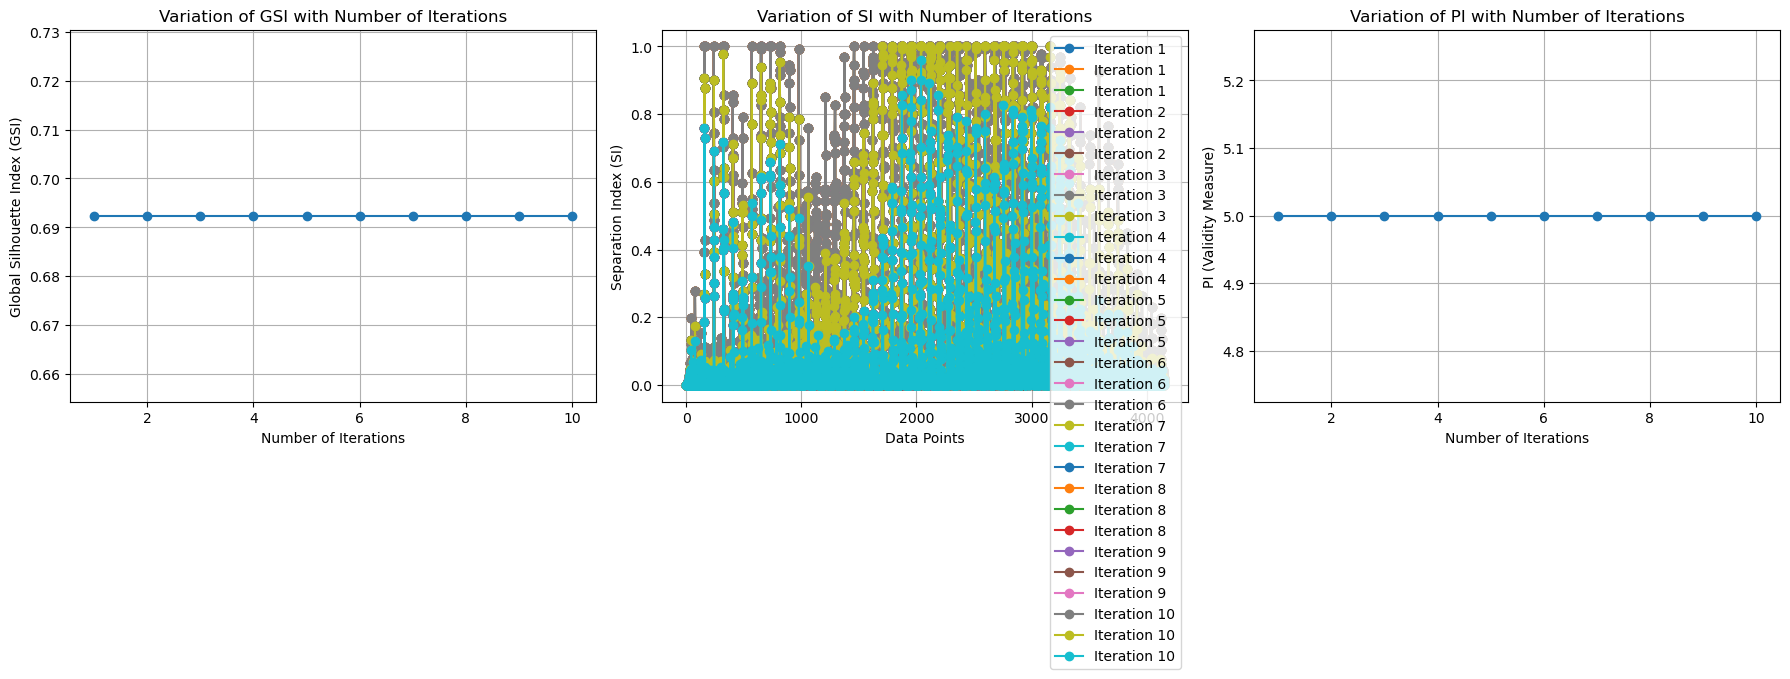

In [ ]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from PIL import Image

def calculate_gsi(x, idx):
    gsi = silhouette_score(x, idx)
    return gsi

def calculate_si(x, idx):
    si_values = silhouette_samples(x, idx)
    return si_values

def calculate_pi(dd, cc_norm, part, nk):
    PI = dd + cc_norm + part + nk
    return PI

def soc(x, nk, factor):
    kmeans = KMeans(n_clusters=nk, random_state=42)
    idx = kmeans.fit_predict(x)
    d1 = np.random.rand(nk)
    m = np.random.randint(1, 100, size=nk)
    return {'idx': idx, 'd1': d1, 'm': m, 'dd': 1, 'cc_norm': 1, 'part': 1}

def run_algorithm_and_capture_gsi_si_pi(image_path, nk, max_iter=10):
    img = np.array(Image.open(image_path)).astype(float)
    img /= 255.0  # Normalize pixel values to the range [0, 1]

    x = img.reshape((-1, 3))

    GS = np.zeros(max_iter)
    gsi_values = []
    si_values = []
    pi_values = []

    for iter in range(1, max_iter + 1):
        factor = np.ones(nk)
        result = soc(x, nk, factor)
        idx = result['idx']
        s = silhouette_samples(x, idx)
        S = np.sum(s)
        GS[iter-1] = S / (len(x) - nk)
        gsi = calculate_gsi(x, idx)
        gsi_values.append(gsi)

        if np.any(result['m'] == 0):
            break

        # Calculate SI (Separation Index)
        si_iter = np.sum((s**2)[:, np.newaxis, np.newaxis] * (x - x[idx])**2, axis=0) / np.sum((s**2)[:, np.newaxis], axis=0)
        si_values.append(si_iter)

        pi_iter = calculate_pi(result['dd'], result['cc_norm'], result['part']**2, nk)
        pi_values.append(pi_iter)

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.plot(range(1, len(gsi_values) + 1), gsi_values, marker='o')
    plt.xlabel('Number of Iterations')
    plt.ylabel('Global Silhouette Index (GSI)')
    plt.title('Variation of GSI with Number of Iterations')
    plt.grid(True)

    plt.subplot(1, 3, 2)
    for i in range(len(si_values)):
        plt.plot(range(1, len(si_values[i]) + 1), si_values[i], label=f'Iteration {i + 1}', marker='o')
    plt.xlabel('Data Points')
    plt.ylabel('Separation Index (SI)')
    plt.title('Variation of SI with Number of Iterations')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(range(1, len(pi_values) + 1), pi_values, marker='o')
    plt.xlabel('Number of Iterations')
    plt.ylabel('PI (Validity Measure)')
    plt.title('Variation of PI with Number of Iterations')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return factor

# Example usage
image_path = input("Enter the image file name (including extension): ")
num_clusters = int(input("Number of clusters required: "))
max_iterations = int(input("Number of iterations: "))

final_factor = run_algorithm_and_capture_gsi_si_pi(image_path, num_clusters, max_iter=max_iterations)


In [ ]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
from PIL import Image

def calculate_gsi(x, idx):
    gsi = silhouette_score(x, idx)
    return gsi

def calculate_si(x, idx):
    si_values = silhouette_samples(x, idx)
    return si_values

def calculate_pi(dd, cc_norm, part, nk):
    PI = dd + cc_norm + part + nk
    return PI

def polynomial_equation(delta, *args):
    M, silhouette_values, delta_values = args
    polynomial = sum([silhouette_values[m] * np.prod([(delta - delta_values[k]) / (delta_values[m] - delta_values[k]) for k in range(M) if k != m]) for m in range(M)])
    return polynomial

def calculate_optimal_threshold(silhouette_values, delta_values):
    M = len(delta_values)
    initial_guess = np.mean(delta_values)
    roots = fsolve(polynomial_equation, initial_guess, args=(M, silhouette_values, delta_values))

    max_silhouette = -np.inf
    optimal_threshold = None

    for root in roots:
        silhouette_at_root = polynomial_equation(root, M, silhouette_values, delta_values)
        if silhouette_at_root > max_silhouette:
            max_silhouette = silhouette_at_root
            optimal_threshold = root

    beta_values = [optimal_threshold / delta_m for delta_m in delta_values]

    return optimal_threshold, beta_values

def calculate_delta_and_silhouette(x, idx):
    # Placeholder for calculating delta and silhouette values
    # Replace with your actual logic
    delta_values = np.random.rand(len(idx))
    silhouette_values = silhouette_samples(x, idx)
    return delta_values, silhouette_values

def run_algorithm_and_capture_table(image_path, nk, max_iter):
    img = np.array(Image.open(image_path)).astype(float)
    img /= 255.0  # Normalize pixel values to the range [0, 1]

    x = img.reshape((-1, 3))

    GS = np.zeros(max_iter)
    gsi_values = []
    si_values = []
    pi_values = []
    delta_values_list = []
    optimal_threshold_values = []
    beta_values_list = []

    for iter in range(1, max_iter + 1):
        factor = np.ones(nk)
        result = soc(x, nk, factor)
        idx = result['idx']
        s = silhouette_samples(x, idx)
        S = np.sum(s)
        GS[iter-1] = S / (len(x) - nk)
        gsi = calculate_gsi(x, idx)
        gsi_values.append(gsi)

        if np.any(result['m'] == 0):
            break

        si_iter = np.sum((s[:, np.newaxis, np.newaxis] ** 2) * (x - x[idx][:, np.newaxis]) ** 2, axis=0) / np.sum((s[:, np.newaxis, np.newaxis] ** 2), axis=0)
        si_values.append(si_iter)

        pi_iter = calculate_pi(result['dd'], result['cc_norm'], result['part']**2, nk)
        pi_values.append(pi_iter)

        delta_values, silhouette_values = calculate_delta_and_silhouette(x, idx)
        delta_values_list.append(delta_values)

        optimal_threshold, beta_values = calculate_optimal_threshold(silhouette_values, delta_values)
        optimal_threshold_values.append(optimal_threshold)
        beta_values_list.append(beta_values)

    print(f"{'Num Clusters':<15} {'Delta Values':<50} {'Silhouette Values':<50} {'Optimal Threshold (η)':<25} {'Beta Values':<50} {'GSI':<20} {'Lambda (lamda)':<20}")
    for i in range(max_iter):
        delta_values_str = ', '.join(map(str, delta_values_list[i]))
        si_values_str = ', '.join(map(str, si_values[i].tolist()))
        beta_values_str = ', '.join(map(str, beta_values_list[i]))
        print(f"{nk:<15} {delta_values_str:<50} {si_values_str:<50} {optimal_threshold_values[i]:<25} {beta_values_str:<50} {gsi_values[i]:<20} {0.0:<20}")

# Example usage
image_path = input("Enter the image file name (including extension): ")
num_clusters = int(input("Number of clusters required: "))
max_iterations = int(input("Number of iterations: "))

run_algorithm_and_capture_table(image_path, num_clusters, max_iter=max_iterations)


Enter the image file name (including extension): P2.jpg
Number of clusters required: 2
Number of iterations: 6
